In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.append(str(ROOT))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src_model.config import (
    input_path,
    train_path_v1,
    test_path_v1,
    feature_meta_path_v1,
    comparison_path_v1,
    model_dir,
    target_col,
    train_year,
    test_year
)
from src_model.feature_engineering_v1 import run_feature_engineering_v1
from src_model.training_v1 import train_all_models, load_model_ready_data, get_model_zoo
from src_model.testing_v1 import evaluate_on_test, evaluate_all_saved_models, get_feature_importance, predict_test
from src_model.comparing_v1 import run_full_comparison, summary_report, collect_feature_importances
from src_model.utils import load_json, load_model

sns.set_theme(style = 'whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

print('ROOT:', ROOT)
print('input:', input_path)
print('train years:', train_year, '| test year:', test_year)

ROOT: E:\AI study\HDB_resale_market_analysis
input: E:\AI study\HDB_resale_market_analysis\src_model\..\data\aid\resale_trx_geo.csv
train years: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025] | test year: 2026


In [2]:
fe = run_feature_engineering_v1()
print('n_train:', fe['meta']['n_train'])
print('n_test:', fe['meta']['n_test'])
print('n_features:', len(fe['feature_columns']))
print('\nFeature columns:')
print(fe['feature_columns'])
blocked = ['price_per_sqm', 'to_mrt', 'nearest_mrt', 'lat', 'lon', 'mrt_lat', 'mrt_lon']
present_blocked = [c for c in blocked if c in fe['feature_columns']]
print('\nBlocked columns still in features (should be empty):', present_blocked)
fe['X_train'].head()

2026-09-14 01:59:40 | INFO     | src_model.feature_engineering_v1 | Loading E:\AI study\HDB_resale_market_analysis\src_model\..\data\aid\resale_trx_geo.csv ...
2026-09-14 01:59:41 | INFO     | src_model.feature_engineering_v1 | Loaded shape: (239265, 26)
2026-09-14 01:59:41 | INFO     | src_model.feature_engineering_v1 | Dropped 0 rows with missing target
2026-09-14 01:59:41 | INFO     | src_model.feature_engineering_v1 | Selected 14 feature columns
2026-09-14 01:59:41 | INFO     | src_model.feature_engineering_v1 | Temporal split -> train: 221758 (2017-2025), test: 17507 (year = 2026)
2026-09-14 01:59:43 | INFO     | src_model.feature_engineering_v1 | Saved train -> E:\AI study\HDB_resale_market_analysis\src_model\..\data\model_based\train_v1.csv
2026-09-14 01:59:43 | INFO     | src_model.feature_engineering_v1 | Saved test -> E:\AI study\HDB_resale_market_analysis\src_model\..\data\model_based\test_v1.csv
2026-09-14 01:59:43 | INFO     | src_model.feature_engineering_v1 | Saved meta 

n_train: 221758
n_test: 17507
n_features: 14

Feature columns:
['trx_date', 'trx_year', 'trx_month', 'lease_commence', 'flat_year', 'remaining_lease_month', 'flat_type', 'flat_model', 'storey_midpoint', 'floor_area_sqm', 'subzone', 'zone_id', 'to_city', 'status']

Blocked columns still in features (should be empty): []


,trx_date,trx_year,trx_month,lease_commence,flat_year,remaining_lease_month,flat_type,flat_model,storey_midpoint,floor_area_sqm,subzone,zone_id,to_city,status
0,2017-01-01,2017,1,1979,38,736,2 ROOM,Improved,11,44.00,ANG MO KIO,113,8677.74,ok
1,2017-01-01,2017,1,1978,39,727,3 ROOM,New Generation,2,67.00,ANG MO KIO,113,9782.56,ok
2,2017-01-01,2017,1,1980,37,749,3 ROOM,New Generation,2,67.00,ANG MO KIO,113,10902.03,ok
3,2017-01-01,2017,1,1980,37,745,3 ROOM,New Generation,5,68.00,ANG MO KIO,113,9162.28,ok
4,2017-01-01,2017,1,1980,37,749,3 ROOM,New Generation,2,67.00,ANG MO KIO,113,10942.85,ok


In [3]:
X_train, X_test, y_train, y_test = load_model_ready_data()
print('X_train:', X_train.shape, '| y_train:', y_train.shape)
print('X_test :', X_test.shape, '| y_test :', y_test.shape)
print('\ny_train describe:')
display(y_train.describe())
print('\ny_test describe:')
display(y_test.describe())
meta = load_json(feature_meta_path_v1)
meta

X_train: (221758, 14) | y_train: (221758,)
X_test : (17507, 14) | y_test : (17507,)

y_train describe:


count    221758.00
mean     524527.20
std      186653.10
min      140000.00
25%      385000.00
50%      492888.00
75%      630000.00
max     1658888.00
Name: resale_price, dtype: float64


y_test describe:


count     17507.00
mean     661168.73
std      214008.65
min      238888.00
25%      513888.00
50%      630000.00
75%      780000.00
max     1728000.00
Name: resale_price, dtype: float64

{'feature_columns': ['trx_date',
  'trx_year',
  'trx_month',
  'lease_commence',
  'flat_year',
  'remaining_lease_month',
  'flat_type',
  'flat_model',
  'storey_midpoint',
  'floor_area_sqm',
  'subzone',
  'zone_id',
  'to_city',
  'status'],
 'n_train': 221758,
 'n_test': 17507,
 'train_years': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
 'test_year': 2026,
 'target': 'resale_price',
 'always_drop_v1': ['blk',
  'lat',
  'lon',
  'mrt_band',
  'mrt_lat',
  'mrt_lon',
  'nearest_mrt',
  'postal',
  'search_val',
  'st',
  'to_mrt',
  'to_mrt_km'],
 'forbidden_cols': ['price_per_sqm', 'resale_price']}

In [4]:
zoo = get_model_zoo()
print('Models to train:', list(zoo.keys()))
for name, est in zoo.items():
    print(f'  - {name}: {type(est).__name__}')

Models to train: ['median_baseline_v1', 'linear_regression_v1', 'ridge_v1', 'random_forest_v1', 'xgboost_v1', 'lightgbm_v1']
  - median_baseline_v1: MedianBaseline
  - linear_regression_v1: LinearRegression
  - ridge_v1: Ridge
  - random_forest_v1: RandomForestRegressor
  - xgboost_v1: XGBRegressor
  - lightgbm_v1: LGBMRegressor


In [5]:
result = train_all_models(save = True)
print('\nTrain infos:')
for name, info in result['infos'].items():
    print(name, info)
print('\nSaved under:', model_dir)

2026-09-14 01:59:44 | INFO     | src_model.feature_engineering_v1 | Preprocessor: 9 numeric, 5 categorical
2026-09-14 01:59:44 | INFO     | src_model.training_v1 | Training median_baseline_v1 ...
2026-09-14 01:59:46 | INFO     | src_model.training_v1 | Finished median_baseline_v1 in 2.0 s
2026-09-14 01:59:46 | INFO     | src_model.utils | Saved model -> E:\AI study\HDB_resale_market_analysis\src_model\..\data\..\model\median_baseline_v1.joblib
2026-09-14 01:59:46 | INFO     | src_model.feature_engineering_v1 | Preprocessor: 9 numeric, 5 categorical
2026-09-14 01:59:46 | INFO     | src_model.training_v1 | Training linear_regression_v1 ...
2026-09-14 01:59:50 | INFO     | src_model.training_v1 | Finished linear_regression_v1 in 4.0 s
2026-09-14 01:59:50 | INFO     | src_model.utils | Saved model -> E:\AI study\HDB_resale_market_analysis\src_model\..\data\..\model\linear_regression_v1.joblib
2026-09-14 01:59:50 | INFO     | src_model.feature_engineering_v1 | Preprocessor: 9 numeric, 5 cat


Train infos:
median_baseline_v1 {'name': 'median_baseline_v1', 'train_time_sec': 2.01, 'n_train_samples': 221758, 'model_path': 'E:\\AI study\\HDB_resale_market_analysis\\src_model\\..\\data\\..\\model\\median_baseline_v1.joblib'}
linear_regression_v1 {'name': 'linear_regression_v1', 'train_time_sec': 3.99, 'n_train_samples': 221758, 'model_path': 'E:\\AI study\\HDB_resale_market_analysis\\src_model\\..\\data\\..\\model\\linear_regression_v1.joblib'}
ridge_v1 {'name': 'ridge_v1', 'train_time_sec': 2.22, 'n_train_samples': 221758, 'model_path': 'E:\\AI study\\HDB_resale_market_analysis\\src_model\\..\\data\\..\\model\\ridge_v1.joblib'}
random_forest_v1 {'name': 'random_forest_v1', 'train_time_sec': 71.18, 'n_train_samples': 221758, 'model_path': 'E:\\AI study\\HDB_resale_market_analysis\\src_model\\..\\data\\..\\model\\random_forest_v1.joblib'}
xgboost_v1 {'name': 'xgboost_v1', 'train_time_sec': 6.71, 'n_train_samples': 221758, 'model_path': 'E:\\AI study\\HDB_resale_market_analysis\\s

In [6]:
metrics_df = evaluate_all_saved_models()
display(metrics_df)

2026-09-14 02:01:15 | INFO     | src_model.testing_v1 | lightgbm_v1 | RMSE = 49708  MAE = 35657  MAPE = 5.40%  R2 = 0.9460
2026-09-14 02:01:15 | INFO     | src_model.testing_v1 | linear_regression_v1 | RMSE = 86914  MAE = 60721  MAPE = 9.22%  R2 = 0.8351
2026-09-14 02:01:15 | INFO     | src_model.testing_v1 | median_baseline_v1 | RMSE = 272242  MAE = 204543  MAPE = 27.39%  R2 = -0.6183
2026-09-14 02:01:15 | INFO     | src_model.testing_v1 | random_forest_v1 | RMSE = 47861  MAE = 33578  MAPE = 5.07%  R2 = 0.9500
2026-09-14 02:01:15 | INFO     | src_model.testing_v1 | ridge_v1 | RMSE = 86917  MAE = 60723  MAPE = 9.22%  R2 = 0.8350
2026-09-14 02:01:15 | INFO     | src_model.testing_v1 | xgboost_v1 | RMSE = 44135  MAE = 31388  MAPE = 4.78%  R2 = 0.9575


,rmse,mae,mape,r2,model,n_test
0,44135.10,31387.52,4.78,0.96,xgboost_v1,17507
1,47861.24,33577.91,5.07,0.95,random_forest_v1,17507
2,49707.71,35657.02,5.40,0.95,lightgbm_v1,17507
3,86914.34,60721.24,9.22,0.84,linear_regression_v1,17507
4,86917.01,60723.35,9.22,0.84,ridge_v1,17507
5,272241.60,204543.47,27.39,-0.62,median_baseline_v1,17507


In [7]:
cmp = run_full_comparison(retrain = False, save = True)
print(summary_report(cmp))
print('Saved comparison CSV:', comparison_path_v1)
display(cmp)

2026-09-14 02:01:16 | INFO     | src_model.comparing_v1 | Evaluating on test set ...
2026-09-14 02:01:16 | INFO     | src_model.testing_v1 | lightgbm_v1 | RMSE = 49708  MAE = 35657  MAPE = 5.40%  R2 = 0.9460
2026-09-14 02:01:16 | INFO     | src_model.testing_v1 | linear_regression_v1 | RMSE = 86914  MAE = 60721  MAPE = 9.22%  R2 = 0.8351
2026-09-14 02:01:16 | INFO     | src_model.testing_v1 | median_baseline_v1 | RMSE = 272242  MAE = 204543  MAPE = 27.39%  R2 = -0.6183
2026-09-14 02:01:17 | INFO     | src_model.testing_v1 | random_forest_v1 | RMSE = 47861  MAE = 33578  MAPE = 5.07%  R2 = 0.9500
2026-09-14 02:01:17 | INFO     | src_model.testing_v1 | ridge_v1 | RMSE = 86917  MAE = 60723  MAPE = 9.22%  R2 = 0.8350
2026-09-14 02:01:17 | INFO     | src_model.testing_v1 | xgboost_v1 | RMSE = 44135  MAE = 31388  MAPE = 4.78%  R2 = 0.9575
2026-09-14 02:01:17 | INFO     | src_model.comparing_v1 | Comparison table saved -> E:\AI study\HDB_resale_market_analysis\src_model\..\data\model_based\mod


=== Model Comparison v1 (sorted by RMSE) ===
               model       rmse        mae  mape    r2  n_test
          xgboost_v1  44,135.10  31,387.52  4.78  0.96   17507
    random_forest_v1  47,861.24  33,577.91  5.07  0.95   17507
         lightgbm_v1  49,707.71  35,657.02  5.40  0.95   17507
linear_regression_v1  86,914.34  60,721.24  9.22  0.84   17507
            ridge_v1  86,917.01  60,723.35  9.22  0.84   17507
  median_baseline_v1 272,241.60 204,543.47 27.39 -0.62   17507
HDB Resale Price Prediction – Model Comparison v1
Best model (lowest RMSE): xgboost_v1
  RMSE : 44,135
  MAE  : 31,388
  MAPE : 4.78%
  R²   : 0.9575

All models (RMSE ascending):
  - xgboost_v1           RMSE =     44,135  R² = 0.9575
  - random_forest_v1     RMSE =     47,861  R² = 0.9500
  - lightgbm_v1          RMSE =     49,708  R² = 0.9460
  - linear_regression_v1 RMSE =     86,914  R² = 0.8351
  - ridge_v1             RMSE =     86,917  R² = 0.8350
  - median_baseline_v1   RMSE =    272,242  R² = -0.6

,rmse,mae,mape,r2,model,n_test
0,44135.10,31387.52,4.78,0.96,xgboost_v1,17507
1,47861.24,33577.91,5.07,0.95,random_forest_v1,17507
2,49707.71,35657.02,5.40,0.95,lightgbm_v1,17507
3,86914.34,60721.24,9.22,0.84,linear_regression_v1,17507
4,86917.01,60723.35,9.22,0.84,ridge_v1,17507
5,272241.60,204543.47,27.39,-0.62,median_baseline_v1,17507


In [8]:
fi_dict = collect_feature_importances(top_n=20)
for name, table in fi_dict.items():
    print('\n===', name, '===')
    display(table.head(15))

2026-09-14 02:01:17 | INFO     | src_model.comparing_v1 | FI for lightgbm_v1: 20 rows
2026-09-14 02:01:17 | INFO     | src_model.comparing_v1 | FI for linear_regression_v1: 20 rows
2026-09-14 02:01:17 | INFO     | src_model.testing_v1 | Model has no feature_importances_ or coef_.
2026-09-14 02:01:18 | INFO     | src_model.comparing_v1 | FI for random_forest_v1: 20 rows
2026-09-14 02:01:18 | INFO     | src_model.comparing_v1 | FI for ridge_v1: 20 rows
2026-09-14 02:01:18 | INFO     | src_model.comparing_v1 | FI for xgboost_v1: 20 rows



=== lightgbm_v1 ===


,feature,importance
0,to_city,1639.00
1,floor_area_sqm,1419.00
2,lease_commence,1324.00
3,trx_year,539.00
4,zone_id,446.00
5,storey_midpoint,403.00
6,remaining_lease_month,307.00
7,flat_year,171.00
8,subzone_BUKIT TIMAH,130.00
9,flat_model_DBSS,127.00



=== linear_regression_v1 ===


,feature,coefficient
0,flat_model_Terrace,308921.19
1,subzone_BUKIT TIMAH,164930.48
2,flat_model_Type S2,162604.98
3,subzone_TANGLIN,157648.38
4,subzone_SUNGEI KADUT,152683.03
5,subzone_CHANGI,127811.84
6,flat_model_Type S1,125984.99
7,flat_model_3Gen,-119622.60
8,flat_model_2-room,-117786.52
9,subzone_SENGKANG,-107207.34


...

,feature,importance
0,floor_area_sqm,0.42
1,to_city,0.22
2,trx_year,0.18
3,lease_commence,0.09
4,storey_midpoint,0.02
5,remaining_lease_month,0.01
6,zone_id,0.01
7,flat_model_Model A,0.01
8,flat_model_DBSS,0.00
9,subzone_BISHAN,0.00



=== ridge_v1 ===


,feature,coefficient
0,flat_model_Terrace,306281.10
1,subzone_BUKIT TIMAH,164806.44
2,flat_model_Type S2,161517.07
3,subzone_TANGLIN,153980.24
4,subzone_SUNGEI KADUT,147378.00
5,subzone_CHANGI,125507.47
6,flat_model_Type S1,125372.72
7,flat_model_3Gen,-117501.67
8,flat_model_2-room,-117093.58
9,subzone_SENGKANG,-106441.49



=== xgboost_v1 ===


,feature,importance
0,flat_type_1 ROOM,0.16
1,flat_type_3 ROOM,0.15
2,flat_type_EXECUTIVE,0.09
3,flat_type_2 ROOM,0.06
4,subzone_OUTRAM,0.04
5,trx_year,0.04
6,floor_area_sqm,0.04
7,flat_type_4 ROOM,0.03
8,subzone_BUKIT MERAH,0.03
9,flat_type_5 ROOM,0.03


Best model: xgboost_v1


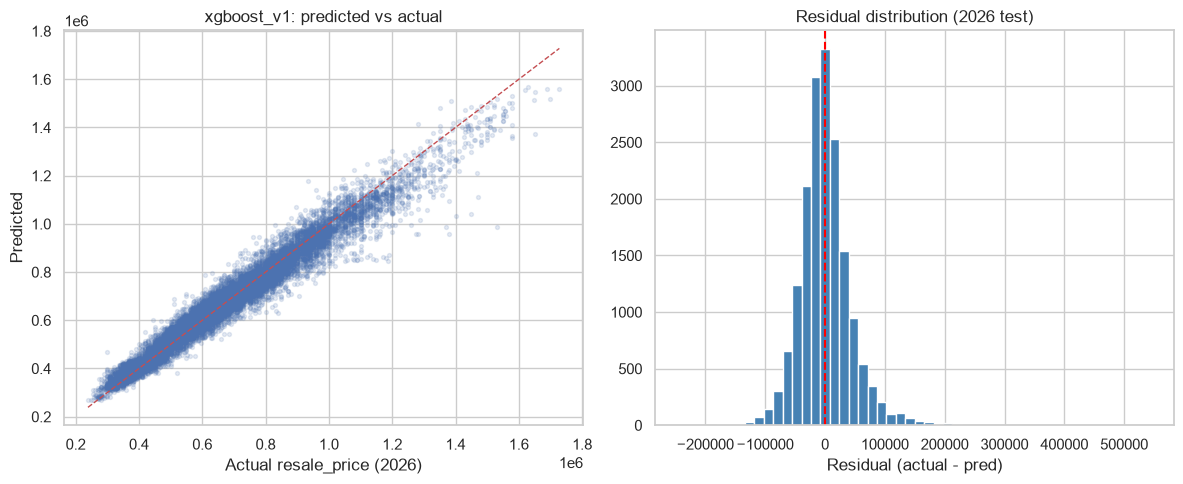

Residual MAE: 31387.516383518017
Residual median: -2898.0625


In [9]:
ok = cmp.dropna(subset = ['rmse']).sort_values('rmse')
best_name = ok.iloc[0]['model']
print('Best model:', best_name)
y_pred = predict_test(best_name, X_test)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, y_pred, alpha = 0.15, s = 8)
mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', lw = 1)
axes[0].set_xlabel('Actual resale_price (2026)')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'{best_name}: predicted vs actual')
resid = y_test.values - y_pred
axes[1].hist(resid, bins = 50, color = 'steelblue', edgecolor = 'white')
axes[1].axvline(0, color = 'red', ls = '--')
axes[1].set_xlabel('Residual (actual - pred)')
axes[1].set_title('Residual distribution (2026 test)')
fig.tight_layout()
plt.show()
print('Residual MAE:', np.mean(np.abs(resid)))
print('Residual median:', np.median(resid))

In [10]:
### ML v1 pipeline summary
'''
1. **Input:** `data/aid/resale_trx_geo.csv`
2. **Target:** `resale_price` (not `price_per_sqm`)
3. **Excluded:** `price_per_sqm` (leakage), all MRT-related columns, raw lat/lon, blk/st ids
4. **Location kept:** `to_city`, `zone_id`, `subzone` (if present)
5. **Split:** train `trx_year` 2017–2025 → test **2026 only** (temporal, not random)
6. **Models:** median baseline, linear, ridge, random forest, XGBoost, LightGBM (if installed)
7. **Artifacts**
   - `data/model_based/train_v1.csv`, `test_v1.csv`, `feature_meta_v1.json`
   - `model/*.joblib`
   - `data/model_based/model_comparison_v1.csv`
'''

'\n1. **Input:** `data/aid/resale_trx_geo.csv`\n2. **Target:** `resale_price` (not `price_per_sqm`)\n3. **Excluded:** `price_per_sqm` (leakage), all MRT-related columns, raw lat/lon, blk/st ids\n4. **Location kept:** `to_city`, `zone_id`, `subzone` (if present)\n5. **Split:** train `trx_year` 2017–2025 → test **2026 only** (temporal, not random)\n6. **Models:** median baseline, linear, ridge, random forest, XGBoost, LightGBM (if installed)\n7. **Artifacts**\n   - `data/model_based/train_v1.csv`, `test_v1.csv`, `feature_meta_v1.json`\n   - `model/*.joblib`\n   - `data/model_based/model_comparison_v1.csv`\n'